In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Загрузка данных
train = pd.read_csv('/kaggle/input/playground-series-s5e8/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s5e8/test.csv')
train.head()
train.info

<bound method DataFrame.info of             id  age          job   marital  education default  balance  \
0            0   42   technician   married  secondary      no        7   
1            1   38  blue-collar   married  secondary      no      514   
2            2   36  blue-collar   married  secondary      no      602   
3            3   27      student    single  secondary      no       34   
4            4   26   technician   married  secondary      no      889   
...        ...  ...          ...       ...        ...     ...      ...   
749995  749995   29     services    single  secondary      no     1282   
749996  749996   69      retired  divorced   tertiary      no      631   
749997  749997   50  blue-collar   married  secondary      no      217   
749998  749998   32   technician   married  secondary      no     -274   
749999  749999   42   technician   married  secondary      no     1559   

       housing loan   contact  day month  duration  campaign  pdays  previous  

In [2]:
# Объединение данных для совместной обработки
test['y'] = 0
data = pd.concat([train.loc[:, 'age':], test.loc[:, 'age':]], axis = 0)

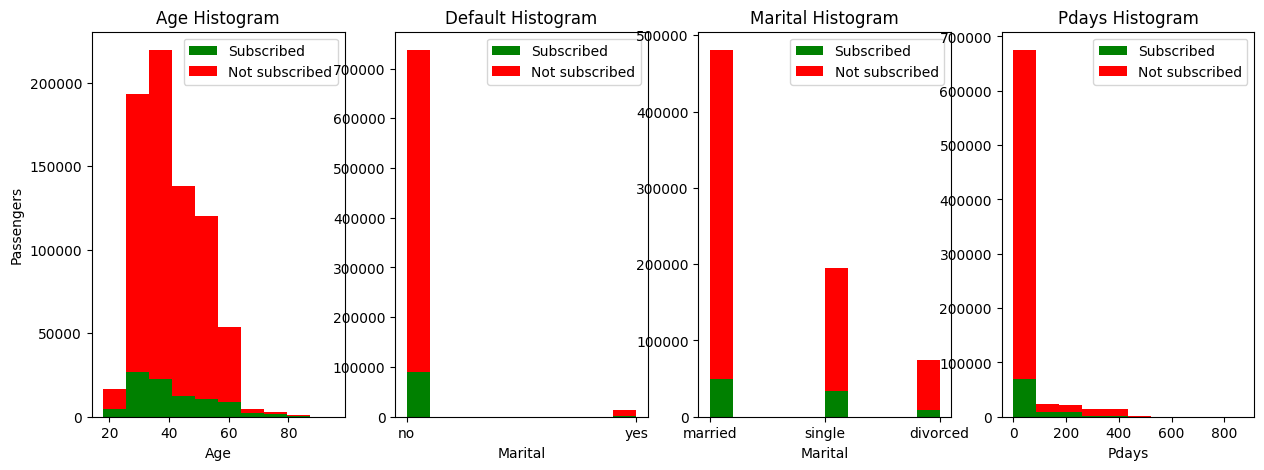

In [3]:
# Анализ данных
plt.figure(figsize=[15,5])
plt.subplot(141)
plt.hist(x = [train[train['y']==1]['age'], train[train['y']==0]['age']], 
         stacked=True, color = ['g','r'],label = ['Subscribed','Not subscribed'])
plt.title('Age Histogram')
plt.xlabel('Age')
plt.ylabel('Passengers')
plt.legend()

plt.subplot(142)
plt.hist(x = [train[train['y']==1]['default'], train[train['y']==0]['default']], 
         stacked=True, color = ['g','r'],label = ['Subscribed','Not subscribed'])
plt.title('Default Histogram')
plt.xlabel('Marital')
plt.legend()

plt.subplot(143)
plt.hist(x = [train[train['y']==1]['marital'], train[train['y']==0]['marital']], 
         stacked=True, color = ['g','r'],label = ['Subscribed','Not subscribed'])
plt.title('Marital Histogram')
plt.xlabel('Marital')
plt.legend()

plt.subplot(144)
plt.hist(x = [train[train['y']==1]['pdays'], train[train['y']==0]['pdays']], 
         stacked=True, color = ['g','r'],label = ['Subscribed','Not subscribed'])
plt.title('Pdays Histogram')
plt.xlabel('Pdays')
plt.legend()

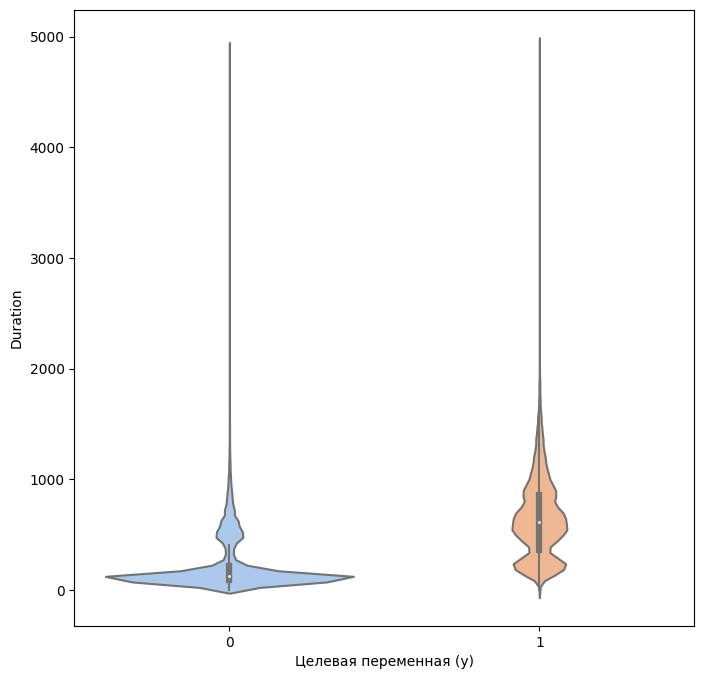

In [4]:
plt.figure(figsize=(8, 8))
sns.violinplot(x='y', y='duration', data=data, palette='pastel')
plt.xlabel('Целевая переменная (y)')
plt.ylabel('Duration')
plt.show()

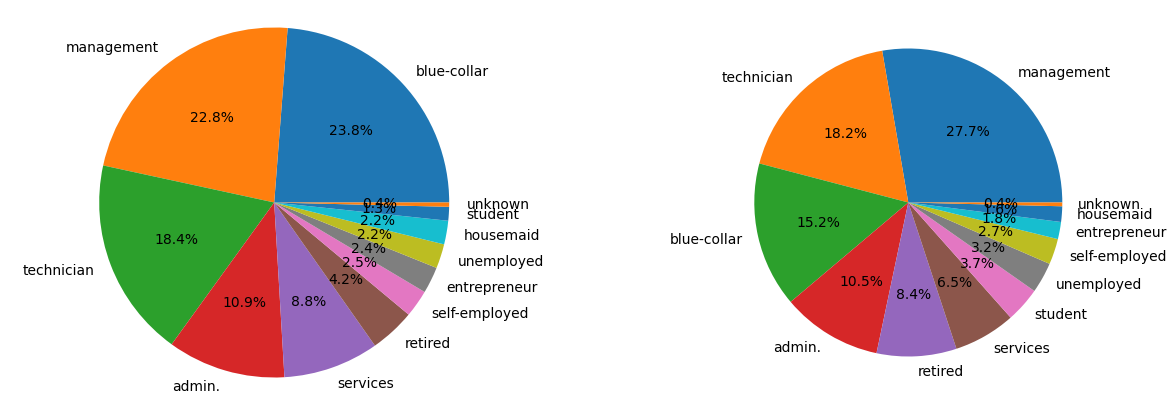

In [5]:
plt.figure(figsize=[15,5])

plt.subplot(121)
grouped = data[train['y'] == 0]['job'].value_counts()
plt.pie(
    grouped,
    labels=grouped.index,
    autopct='%1.1f%%',
)
plt.axis('equal')

plt.subplot(122)
grouped = data[train['y'] == 1]['job'].value_counts()
plt.pie(
    grouped,
    labels=grouped.index,
    autopct='%1.1f%%',
)

plt.show()

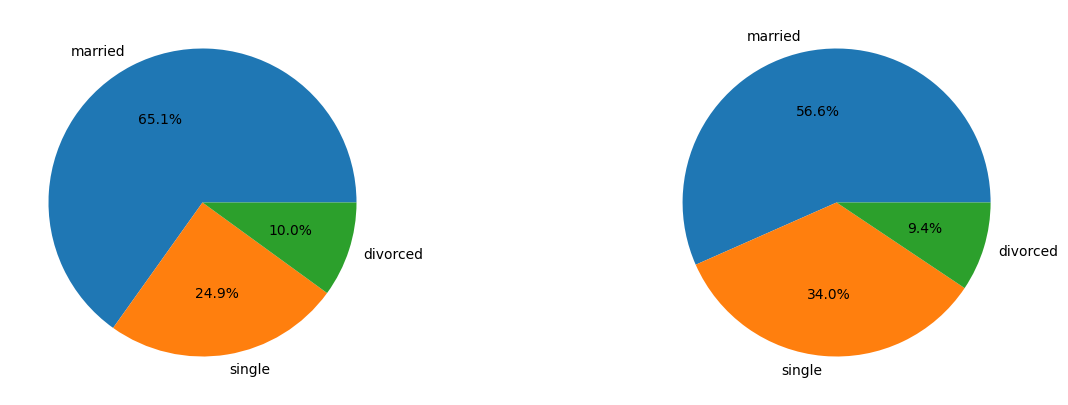

In [6]:
plt.figure(figsize=[15,5])

plt.subplot(121)
grouped = data[train['y'] == 0]['marital'].value_counts()
plt.pie(
    grouped,
    labels=grouped.index,
    autopct='%1.1f%%',
)

plt.subplot(122)
grouped = data[train['y'] == 1]['marital'].value_counts()
plt.pie(
    grouped,
    labels=grouped.index,
    autopct='%1.1f%%',
)

plt.show()

In [7]:
data['pdays'] = data['pdays'].apply(lambda x: True if 10**5 == -1 else x)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   age        1000000 non-null  int64 
 1   job        1000000 non-null  object
 2   marital    1000000 non-null  object
 3   education  1000000 non-null  object
 4   default    1000000 non-null  object
 5   balance    1000000 non-null  int64 
 6   housing    1000000 non-null  object
 7   loan       1000000 non-null  object
 8   contact    1000000 non-null  object
 9   day        1000000 non-null  int64 
 10  month      1000000 non-null  object
 11  duration   1000000 non-null  int64 
 12  campaign   1000000 non-null  int64 
 13  pdays      1000000 non-null  int64 
 14  previous   1000000 non-null  int64 
 15  poutcome   1000000 non-null  object
 16  y          1000000 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 137.3+ MB


In [8]:
from sklearn.preprocessing import RobustScaler

dummy_columns = data.select_dtypes(include=['object']).columns.tolist()
other_columns = list(set(data.columns)-set(dummy_columns))
dummy_df = pd.get_dummies(data[dummy_columns])

data = pd.concat([data, dummy_df], axis=1)
data.drop(dummy_columns, inplace = True, axis = 1)


# Скейлинг данных
rob_scaler = RobustScaler()
data[other_columns] = rob_scaler.fit_transform(data[other_columns])

In [9]:
data['duration_p_h_c_m'] = data['duration']*(data['poutcome_success']+data['housing_no']+ data['contact_cellular']+data['month_sep']+data['month_oct'])
data['duration_balance'] = data['duration']*data['balance']
data['poutcome_months'] = data['poutcome_success']*(data['contact_cellular']+data['month_sep']+data['month_oct']+data['month_mar'])
cols = ['duration_p_h_c_m', 'duration_balance', 'poutcome_months']
data[cols] = rob_scaler.fit_transform(data[cols])

X = data[:len(train)]
correlations = X.corr()['y']
correlations.sort_values(ascending=False)

y                      1.000000
duration               0.519283
duration_p_h_c_m       0.517985
poutcome_success       0.306996
poutcome_months        0.301817
duration_balance       0.189989
housing_no             0.153589
contact_cellular       0.149948
month_sep              0.126990
month_oct              0.126397
balance                0.122513
month_mar              0.122177
previous               0.119552
marital_single         0.090578
pdays                  0.089277
job_retired            0.085545
job_student            0.085325
month_apr              0.085254
education_tertiary     0.085084
loan_no                0.081639
month_dec              0.063401
month_feb              0.060773
job_management         0.050475
default_no             0.030134
job_unemployed         0.028189
poutcome_other         0.020084
contact_telephone      0.010418
age                    0.009523
poutcome_failure       0.009432
education_unknown      0.006685
job_self-employed      0.004354
month_ja

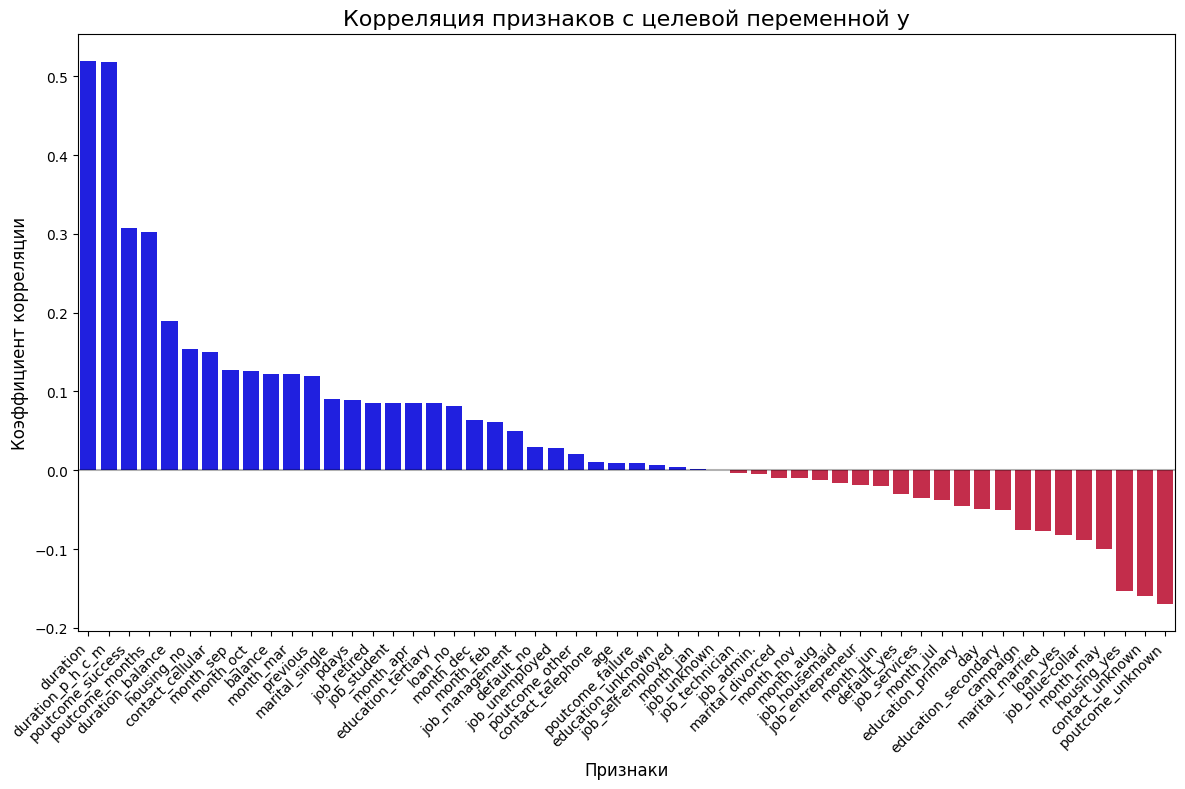

In [10]:
# Сортируем и убираем целевую переменную
correlations_to_plot = correlations.drop('y', errors='ignore').sort_values(ascending=False)

# Создаем DataFrame для seaborn
corr_df = pd.DataFrame({
    'feature': correlations_to_plot.index,
    'correlation': correlations_to_plot.values
})

# Создаем график
plt.figure(figsize=(12, 8))
sns.barplot(data=corr_df, x='feature', y='correlation', 
            palette=['crimson' if x < 0 else 'blue' for x in corr_df['correlation']])

# Настраиваем внешний вид
plt.title('Корреляция признаков с целевой переменной y', fontsize=16)
plt.xlabel('Признаки', fontsize=12)
plt.ylabel('Коэффициент корреляции', fontsize=12)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [11]:
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import optuna
import numpy as np

# Предполагаем, что данные уже подготовлены
y = X['y']
X.drop('y', axis=1, inplace=True)  # Исправлено: axis=1 для столбцов

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

# Функция для оптимизации с помощью Optuna
def objective(trial):
    # Определяем пространство поиска гиперпараметров
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'auc'
    }
    
    # Создаем модель с предложенными параметрами
    model = XGBClassifier(**params)
    
    # Используем кросс-валидацию для оценки качества
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Можно уменьшить n_splits для скорости
    scores = cross_val_score(model, X_train, y_train, 
                           cv=cv, scoring='roc_auc', n_jobs=-1)
    
    return scores.mean()

# Создаем study и запускаем оптимизацию
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, show_progress_bar=True)  # Можно увеличить n_trials

# Выводим результаты оптимизации
print("Лучшие параметры:")
print(study.best_params)
print(f"\nЛучшее ROC-AUC: {study.best_value:.5f}")

# Обучаем финальную модель на лучших параметрах
best_params = study.best_params
best_params.update({
    'random_state': 42,
    'use_label_encoder': False,
    'eval_metric': 'auc'
})

model_xgb = XGBClassifier(**best_params)

# Кросс-валидация на лучших параметрах
scv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(model_xgb, X_train, y_train, 
                       cv=scv, scoring='roc_auc', n_jobs=-1)
print(f"\nCross validation ROC-AUC с лучшими параметрами: {scores.mean():.5f} (+/- {scores.std()*2:.5f})")

[I 2025-08-27 11:48:03,883] A new study created in memory with name: no-name-76a4f2db-03a1-4511-82d3-2d78fdfbc030


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-08-27 11:51:40,281] Trial 1 finished with value: 0.9589996165671707 and parameters: {'n_estimators': 278, 'learning_rate': 0.018860459684125412, 'max_depth': 6, 'subsample': 0.8692860104697837, 'colsample_bytree': 0.608354471449444, 'reg_alpha': 3.1383797761586543, 'reg_lambda': 7.583847736509293, 'min_child_weight': 8, 'gamma': 4.881257116197234}. Best is trial 0 with value: 0.9598229129225277.
[I 2025-08-27 11:53:45,407] Trial 2 finished with value: 0.9670529007747308 and parameters: {'n_estimators': 693, 'learning_rate': 0.21788688343955942, 'max_depth': 6, 'subsample': 0.6463249274777565, 'colsample_bytree': 0.9845411055961947, 'reg_alpha': 1.0353890822402145, 'reg_lambda': 8.985938136155173, 'min_child_weight': 7, 'gamma': 4.201364067301656}. Best is trial 2 with value: 0.9670529007747308.
[I 2025-08-27 11:55:59,262] Trial 3 finished with value: 0.9634646884060603 and parameters: {'n_estimators': 596, 'learning_rate': 0.043203216980920264, 'max_depth': 4, 'subsample': 0.88

In [12]:
# Обучаем модель на всех тренировочных данных
model_xgb.fit(X_train, y_train)

# Предсказания на валидационной выборке
predictions_proba = model_xgb.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, predictions_proba)
print(f"\nROC-AUC на валидационной выборке: {val_auc:.5f}")


ROC-AUC на валидационной выборке: 0.96766


In [13]:
X_test = data[len(train):].drop('y', axis=1)
predictions = model_xgb.predict_proba(X_test)[:, 1]

# Сабмит
submission = pd.DataFrame({
    'id': test['id'],
    'y': predictions
})
submission.to_csv('submission.csv', index=False)
print("Сабмит сохранен!")

Сабмит сохранен!


In [14]:
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import optuna

# Функции для оптимизации отдельных моделей
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'auc'
    }
    
    model = XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# Оптимизация отдельных моделей
print("Оптимизация XGBoost...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=10, show_progress_bar=True)

[I 2025-08-27 12:15:50,543] A new study created in memory with name: no-name-d4ef880b-4d1c-4024-8e14-e875480c6965


Оптимизация XGBoost...


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-08-27 12:16:58,604] Trial 0 finished with value: 0.9604997208875744 and parameters: {'n_estimators': 263, 'learning_rate': 0.05329121258485082, 'max_depth': 4, 'subsample': 0.6166245496813824, 'colsample_bytree': 0.6528003692265928, 'reg_alpha': 7.527496495704934, 'reg_lambda': 7.674248271026013, 'min_child_weight': 7, 'gamma': 2.9938191471353894}. Best is trial 0 with value: 0.9604997208875744.
[I 2025-08-27 12:20:33,737] Trial 1 finished with value: 0.9630419433432309 and parameters: {'n_estimators': 743, 'learning_rate': 0.014057459957633968, 'max_depth': 6, 'subsample': 0.7915284671393765, 'colsample_bytree': 0.7666043291899645, 'reg_alpha': 3.6153848171827785, 'reg_lambda': 8.529818014264368, 'min_child_weight': 4, 'gamma': 3.110127032629708}. Best is trial 1 with value: 0.9630419433432309.
[I 2025-08-27 12:21:22,731] Trial 2 finished with value: 0.9617413902046904 and parameters: {'n_estimators': 186, 'learning_rate': 0.15825168892312264, 'max_depth': 3, 'subsample': 0.94

In [15]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 42
    }
    
    model = RandomForestClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print("Оптимизация Random Forest...")
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=6, show_progress_bar=True)

[I 2025-08-27 12:38:08,247] A new study created in memory with name: no-name-edc7b614-d18c-4560-9a7b-530be8d66a2c


Оптимизация Random Forest...


  0%|          | 0/6 [00:00<?, ?it/s]

[I 2025-08-27 12:59:40,130] Trial 0 finished with value: 0.8871479012279183 and parameters: {'n_estimators': 268, 'max_depth': 3, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 0.8871479012279183.
[I 2025-08-27 14:43:29,681] Trial 1 finished with value: 0.9214419845714291 and parameters: {'n_estimators': 812, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': False}. Best is trial 1 with value: 0.9214419845714291.
[I 2025-08-27 15:10:55,028] Trial 2 finished with value: 0.9521150968268959 and parameters: {'n_estimators': 942, 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False}. Best is trial 2 with value: 0.9521150968268959.
[I 2025-08-27 15:22:26,918] Trial 3 finished with value: 0.9397162018280131 and parameters: {'n_estimators': 770, 'max_depth': 4, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features'

In [16]:
def objective_gb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42
    }
    
    model = GradientBoostingClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()



print("Оптимизация Gradient Boosting...")
study_gb = optuna.create_study(direction='maximize')
study_gb.optimize(objective_gb, n_trials=6, show_progress_bar=True)

[I 2025-08-27 15:48:06,562] A new study created in memory with name: no-name-c2718a56-2400-48af-ae67-1ad015a25360


Оптимизация Gradient Boosting...


  0%|          | 0/6 [00:00<?, ?it/s]

[I 2025-08-27 16:17:37,750] Trial 0 finished with value: 0.955954585819487 and parameters: {'n_estimators': 435, 'learning_rate': 0.027731588951522446, 'max_depth': 3, 'subsample': 0.7879355446998932, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 0 with value: 0.955954585819487.
[I 2025-08-27 17:33:23,695] Trial 1 finished with value: 0.9683236415171924 and parameters: {'n_estimators': 398, 'learning_rate': 0.05542870205974665, 'max_depth': 8, 'subsample': 0.884759127170869, 'min_samples_split': 17, 'min_samples_leaf': 7, 'max_features': None}. Best is trial 1 with value: 0.9683236415171924.
[I 2025-08-27 17:44:39,415] Trial 2 finished with value: 0.9654612719984226 and parameters: {'n_estimators': 452, 'learning_rate': 0.2913646127033966, 'max_depth': 7, 'subsample': 0.830320087016174, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 1 with value: 0.9683236415171924.
[I 2025-08-27 17:49:39,817] Trial 3 finish

In [ ]:
# Получаем лучшие параметры для каждой модели
best_xgb_params = study_xgb.best_params
best_rf_params = study_rf.best_params
best_gb_params = study_gb.best_params

# Создаем оптимизированные модели
xgb_model = XGBClassifier(**best_xgb_params, random_state=42, use_label_encoder=False, eval_metric='auc')
rf_model = RandomForestClassifier(**best_rf_params, random_state=42)
gb_model = GradientBoostingClassifier(**best_gb_params, random_state=42)

# Функция для оптимизации голосующего ансамбля
def objective_ensemble(trial):
    # Веса для каждой модели в ансамбле
    xgb_weight = trial.suggest_float('xgb_weight', 0.1, 3.0)
    rf_weight = trial.suggest_float('rf_weight', 0.1, 3.0)
    gb_weight = trial.suggest_float('gb_weight', 0.1, 3.0)
    
    # Создаем ансамбль с весами
    ensemble = VotingClassifier(
        estimators=[
            ('xgb', xgb_model),
            ('rf', rf_model),
            ('gb', gb_model)
        ],
        voting='soft',
        weights=[xgb_weight, rf_weight, gb_weight]
    )
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(ensemble, X_val, y_val, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# Оптимизация весов ансамбля
print("Оптимизация весов ансамбля...")
study_ensemble = optuna.create_study(direction='maximize')
study_ensemble.optimize(objective_ensemble, n_trials=20, show_progress_bar=True)

# Лучшие веса для ансамбля
best_weights = study_ensemble.best_params
print(f"Лучшие веса ансамбля: {best_weights}")

# Создаем финальный ансамбль с оптимизированными весами
final_ensemble = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('rf', rf_model),
        ('gb', gb_model)
    ],
    voting='soft',
    weights=[best_weights['xgb_weight'], best_weights['rf_weight'], best_weights['gb_weight']]
)

# Обучаем и оцениваем финальный ансамбль
print("\nОценка финального ансамбля:")
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
ensemble_scores = cross_val_score(final_ensemble, X_train, y_train, 
                                cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"Ансамбль ROC-AUC: {ensemble_scores.mean():.5f} (+/- {ensemble_scores.std()*2:.5f})")

# Также оцениваем отдельные модели для сравнения
print("\nСравнение с отдельными моделями:")

# XGBoost
xgb_scores = cross_val_score(xgb_model, X_train, y_train, 
                           cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"XGBoost ROC-AUC: {xgb_scores.mean():.5f} (+/- {xgb_scores.std()*2:.5f})")

# Random Forest
rf_scores = cross_val_score(rf_model, X_train, y_train, 
                          cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"Random Forest ROC-AUC: {rf_scores.mean():.5f} (+/- {rf_scores.std()*2:.5f})")

# Gradient Boosting
gb_scores = cross_val_score(gb_model, X_train, y_train, 
                          cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"Gradient Boosting ROC-AUC: {gb_scores.mean():.5f} (+/- {gb_scores.std()*2:.5f})")

# Обучаем финальный ансамбль на всех данных
print("\nОбучение финального ансамбля на всех тренировочных данных...")
final_ensemble.fit(X_train, y_train)

# Предсказания на валидационной выборке
val_preds = final_ensemble.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, val_preds)
print(f"ROC-AUC на валидационной выборке: {val_auc:.5f}")

# Сохраняем лучшие параметры для всех моделей
best_params_summary = {
    'XGBoost': best_xgb_params,
    'RandomForest': best_rf_params,
    'GradientBoosting': best_gb_params,
    'Ensemble_weights': best_weights,
    'Final_ensemble_auc': ensemble_scores.mean(),
    'Validation_auc': val_auc
}

print("\nИтоговые лучшие параметры:")
for model, params in best_params_summary.items():
    print(f"{model}: {params}")

[I 2025-08-27 18:05:00,854] A new study created in memory with name: no-name-c44639b4-e623-4c00-805e-a6f8757aee3b


Оптимизация весов ансамбля...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-08-27 18:13:33,244] Trial 0 finished with value: 0.9618641056828967 and parameters: {'xgb_weight': 1.9972231190047285, 'rf_weight': 2.7692730874874942, 'gb_weight': 2.187540166795621}. Best is trial 0 with value: 0.9618641056828967.
[I 2025-08-27 18:22:05,549] Trial 1 finished with value: 0.9617032566910673 and parameters: {'xgb_weight': 0.745684562415153, 'rf_weight': 1.8357538114624652, 'gb_weight': 1.5475537832670063}. Best is trial 0 with value: 0.9618641056828967.
[I 2025-08-27 18:30:34,242] Trial 2 finished with value: 0.9619498122206291 and parameters: {'xgb_weight': 0.8370509195323972, 'rf_weight': 2.128916987272319, 'gb_weight': 2.268930390992263}. Best is trial 2 with value: 0.9619498122206291.
[I 2025-08-27 18:39:07,221] Trial 3 finished with value: 0.962997641465684 and parameters: {'xgb_weight': 2.926998419718461, 'rf_weight': 0.1972379331929464, 'gb_weight': 2.7872692770621104}. Best is trial 3 with value: 0.962997641465684.
[I 2025-08-27 18:47:42,606] Trial 4 fin